# Axicon 1 (α = 5°) — measured Bessel zone vs Rao theory vs QDHT model

**Dataset**: `auto_scan-2026-07-24_17-32-49` — first scan after installing
axicon 1 (5°), input = post-telescope Gaussian, D = 9.50 mm (1/e², adopted
mean from `beam_gaussian_fit_analysis_2026_07_24`). 25 X–Z slices,
y = 5.00–17.00 cm after the axicon in 0.5 cm steps (`MeasuredFrom:
"axicon1"`).

**Predictions** (λ = 650 nm, w₀ = 4.75 mm):

| quantity | Rao (n = 1.457, k·sin((n−1)α)) | QDHT (n = 1.4585, k·(n−1)·tanα) |
|---|---|---|
| k_r | 3.854×10⁵ rad/m | 3.878×10⁵ rad/m (+0.6 %) |
| zmax = k·w₀/k_r | 11.91 cm | 11.84 cm |
| envelope peak (zmax/2) | 5.96 cm | — |
| core first zero 2.405/k_r | 6.24 µm | 6.20 µm |
| J₀² fringe period π/k_r | 8.15 µm | 8.10 µm |

The two modules use slightly different refractive indices and small-angle
conventions; the 0.6 % k_r difference is invisible at our resolution, so both
are shown as-is.

Two comparisons:

1. **Axial**: per-slice peak-pixel rate (max unsaturated `Max` ÷ its
   `Exposure_us`) vs the Rao envelope I(z) ∝ (z/zmax)·exp(−2(z/zmax)²) and
   the QDHT on-axis curve for a single axicon on the measured Gaussian.
2. **Radial**: azimuthal-mean profiles of the brightest raw frame at
   y = 6, 9, 12 cm (native 3.45 µm pixels, half-pixel radial bins) vs the
   QDHT J₀² pattern — including a "pixel-sampled" model that replays the
   camera's pixel integration and the binning, since the 8.1 µm fringes sit
   barely above Nyquist.

In [1]:
import glob
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "profiler"))

from simulator.bessel_axicon import AxiconParams, axial_envelope, zmax_axicon
from simulator.qdht_axicon import (QDHT, propagate_spectrum, axicon_kr, K0,
                                   mm as MM)

RUN = REPO / "profiler/data/auto_scan-2026-07-24_17-32-49"
PX_UM = 3.45                     # native camera pixel (µm)
D_IN_MM = 9.50                   # 1/e² input diameter after telescope
W0_UM = D_IN_MM * 1e3 / 2        # 1/e² radius, µm
ALPHA_DEG = 5.0

P = AxiconParams(wavelength_nm=650, n=1.457, alpha_deg=ALPHA_DEG)
KR_RAO = P.k_r
ZMAX_M = zmax_axicon(W0_UM, P)
KR_Q = axicon_kr(ALPHA_DEG)
print(f"k_r: Rao {KR_RAO:.4e}, QDHT {KR_Q:.4e} rad/m "
      f"({100 * (KR_Q / KR_RAO - 1):+.2f} %)")
print(f"zmax = {ZMAX_M * 100:.2f} cm, envelope peak at {ZMAX_M * 50:.2f} cm")
print(f"core first zero {2.405 / KR_RAO * 1e6:.2f} µm, "
      f"fringe period {np.pi / KR_RAO * 1e6:.2f} µm")

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "axicon1_bessel_analysis_2026_07_24"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

k_r: Rao 3.8540e+05, QDHT 3.8776e+05 rad/m (+0.61 %)
zmax = 11.91 cm, envelope peak at 5.96 cm
core first zero 6.24 µm, fringe period 8.15 µm


## Axial reduction — peak-pixel rate per slice

For each slice, the metric is the maximum over unsaturated lit frames of
`Max / Exposure_us` (counts/µs) — an exposure-independent stand-in for peak
intensity. Saturated frames are excluded; a slice is **flagged** when its
best *unsaturated* frame needed an anomalously long exposure (> 10 ms):
that is the find-beam ×-escalation bug landing on the dim annulus-transition
region past zmax, and the number is not comparable to the rest.

The reduction is cached in `reductions/ax1_reduction_2026_07_24.json`
(delete it to force a re-reduction). Composites are ensured as a
side-effect for anyone re-running slice imagery later.

In [2]:
# --- ensure composites + reduce frames.jsonl -> peak rate per slice ---------
from composite import CompositeConfig, composite_slice

CACHE = Path("reductions/ax1_reduction_2026_07_24.json")
cfg = CompositeConfig(PixelSize_um=PX_UM, Downsample=2, FlipX=True,
                      FlipZ=True, Transpose=False, SubtractBackground=True,
                      IncludeDarkFrames=False, Colormap="inferno")

if CACHE.exists():
    reduction = json.load(open(CACHE))
    print(f"loaded cached reduction ({len(reduction)} slices)")
else:
    reduction = []
    for sd in sorted(glob.glob(str(RUN / "y*cm"))):
        sd = Path(sd)
        if not (sd / "composite_meta.json").exists():
            try:
                composite_slice(str(sd), cfg)
            except Exception as e:
                # a slice that cannot composite still reduces from its
                # manifest below, but say so rather than hiding it
                print(f"COMPOSITE FAIL {sd.name}: {type(e).__name__}: {e}")
        lit = []
        n_sat = 0
        for line in open(sd / "frames.jsonl"):
            if not line.strip():
                continue
            rec = json.loads(line)
            name = Path(rec["Path"]).name
            if "background" in name or "-dark" in name:
                continue
            if rec.get("SaturatedPixelCount", 0) > 0:
                n_sat += 1
                continue
            lit.append(rec)
        best = max(lit, key=lambda r: r["Max"] / r["Extra"]["Exposure_us"])
        reduction.append(dict(
            slice=sd.name, beam_y_cm=best["Extra"]["BeamY_mm"] / 10.0,
            n_lit=len(lit), n_sat=n_sat,
            peak=dict(rate=best["Max"] / best["Extra"]["Exposure_us"],
                      max=best["Max"], T=best["Extra"]["Exposure_us"],
                      path=Path(best["Path"]).name,
                      x=best["GantryPosition_mm"]["x_mm"],
                      z=best["GantryPosition_mm"]["z_mm"])))
    CACHE.parent.mkdir(exist_ok=True)
    json.dump(reduction, open(CACHE, "w"))
    print(f"reduced and cached {len(reduction)} slices")

y_all = np.array([s["beam_y_cm"] for s in reduction])
rate_all = np.array([s["peak"]["rate"] for s in reduction])
flagged = np.array([s["n_sat"] > 0 and s["peak"]["T"] > 10_000
                    for s in reduction])
for s in reduction:
    p = s["peak"]
    print(f"y={s['beam_y_cm']:5.2f}  rate={p['rate']:9.3e} counts/µs  "
          f"max={p['max']:3.0f}  T={p['T'] / 1e3:7.2f} ms  sat={s['n_sat']:2d}"
          + ("  ** FLAGGED" if flagged[list(reduction).index(s)] else ""))

loaded cached reduction (25 slices)
y= 5.00  rate=4.828e+00 counts/µs  max=149  T=   0.03 ms  sat= 0
y= 5.50  rate=4.990e+00 counts/µs  max=154  T=   0.03 ms  sat= 0
y= 6.00  rate=4.569e+00 counts/µs  max=141  T=   0.03 ms  sat= 0
y= 6.50  rate=3.629e+00 counts/µs  max=112  T=   0.03 ms  sat= 0
y= 7.00  rate=4.213e+00 counts/µs  max=130  T=   0.03 ms  sat= 0
y= 7.50  rate=4.958e+00 counts/µs  max=153  T=   0.03 ms  sat= 0
y= 8.00  rate=4.213e+00 counts/µs  max=130  T=   0.03 ms  sat= 0
y= 8.50  rate=4.439e+00 counts/µs  max=137  T=   0.03 ms  sat= 0
y= 9.00  rate=3.338e+00 counts/µs  max=103  T=   0.03 ms  sat= 0
y= 9.50  rate=2.949e+00 counts/µs  max= 91  T=   0.03 ms  sat= 0
y=10.00  rate=2.616e+00 counts/µs  max=143  T=   0.05 ms  sat= 0
y=10.50  rate=2.470e+00 counts/µs  max=135  T=   0.05 ms  sat= 0
y=11.00  rate=2.506e+00 counts/µs  max=137  T=   0.05 ms  sat= 0
y=11.50  rate=2.378e+00 counts/µs  max=130  T=   0.05 ms  sat= 0
y=12.00  rate=2.067e+00 counts/µs  max=113  T=   0.05 

## Pixel sampling of a 6 µm core — expected scatter of the metric

The Bessel core (first zero 6.2 µm, FWHM ≈ 5.8 µm) is barely wider than one
3.45 µm pixel, so the *peak-pixel* value depends on where the core lands
relative to the pixel grid. Averaging J₀²(k_r·r) over one pixel: a
core-centered pixel reads 0.86 of the true on-axis intensity; a
corner-straddling core reads 0.56. The metric therefore scatters over
roughly **[0.56, 0.86] × I(0)** slice-to-slice — a ±20 % band, biased low —
and that is the dominant noise on the axial plot (exposures are known to
0.1 µs; counts to 1 part in ~130).

In [3]:
# --- peak-pixel acceptance band from sub-pixel alignment ---------------------
g = (np.arange(24) + 0.5) / 24 * PX_UM - PX_UM / 2
GX, GY = np.meshgrid(g, g)

def peak_pixel_frac(ox_um, oy_um):
    """Pixel-average of the normalized core at sub-pixel offset (ox, oy)."""
    r = np.hypot(GX - ox_um, GY - oy_um) * 1e-6
    return (j0(KR_RAO * r) ** 2).mean()

f_best = peak_pixel_frac(0, 0)
f_worst = peak_pixel_frac(PX_UM / 2, PX_UM / 2)
print(f"peak-pixel fraction of true I(0): centered {f_best:.3f}, "
      f"corner {f_worst:.3f} -> {100 * (1 - f_worst / f_best):.0f} % scatter")

peak-pixel fraction of true I(0): centered 0.864, corner 0.564 -> 35 % scatter


saved images/axicon1_bessel_analysis_2026_07_24/axial_vs_theory.png


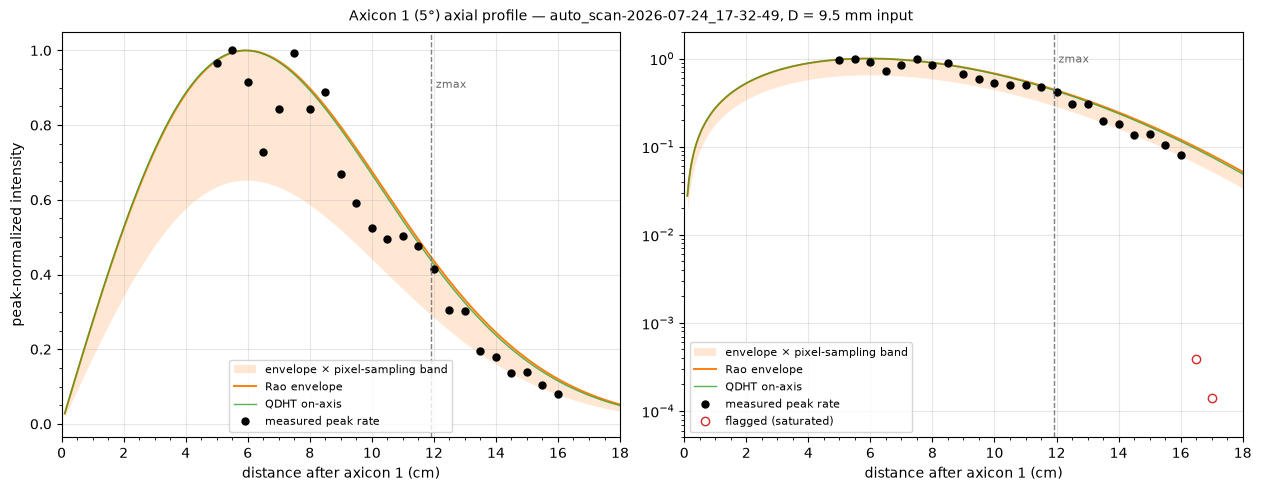

In [4]:
# --- axial comparison figure -------------------------------------------------
z_fine = np.linspace(1e-3, 0.20, 400)
rao = axial_envelope(z_fine, W0_UM, P)
rao = rao / rao.max()

N_Q, R_Q = 4096, 12 * MM
q = QDHT(N_Q, R_Q)
assert q.kr_max > 2.5 * KR_Q, "radial grid too coarse for the axicon cone"
E0 = np.exp(-(q.r / (W0_UM * 1e-6)) ** 2) * np.exp(-1j * KR_Q * q.r)
y0 = q.forward(E0)
qd_onax = q.onax(propagate_spectrum(y0, q.kr, K0, z_fine))
qd_onax = qd_onax / qd_onax.max()

ok = ~flagged
norm = rate_all / rate_all[ok].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8),
                               constrained_layout=True)
for ax in (ax1, ax2):
    ax.fill_between(z_fine * 100, rao * f_worst / f_best, rao,
                    color="tab:orange", alpha=0.18, lw=0,
                    label="envelope × pixel-sampling band")
    ax.plot(z_fine * 100, rao, "-", color="tab:orange", lw=1.4,
            label="Rao envelope")
    ax.plot(z_fine * 100, qd_onax, "-", color="tab:green", lw=1.0, alpha=0.8,
            label="QDHT on-axis")
    ax.plot(y_all[ok], norm[ok], "ko", ms=5, label="measured peak rate")
    ax.axvline(ZMAX_M * 100, color="0.5", ls="--", lw=1)
    ax.annotate("zmax", (ZMAX_M * 100 + 0.15, 0.9), fontsize=8, color="0.4")
    ax.set_xlabel("distance after axicon 1 (cm)")
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
ax1.set_ylabel("peak-normalized intensity")
ax1.set_xlim(0, 18); ax1.legend(fontsize=8)
ax2.plot(y_all[flagged], norm[flagged], "o", mfc="none", mec="tab:red", ms=6,
         label="flagged (saturated)")
ax2.set_yscale("log"); ax2.set_ylim(5e-5, 2); ax2.set_xlim(0, 18)
ax2.legend(fontsize=8)
fig.suptitle(f"Axicon 1 ({ALPHA_DEG:g}°) axial profile — {RUN.name}, "
             f"D = {D_IN_MM:g} mm input", fontsize=10)
save_fig("axial_vs_theory")
plt.show()

### Reading the axial comparison

- **The envelope shape is confirmed.** From 5 to 16 cm the measured rates
  track (z/zmax)·exp(−2(z/zmax)²) with zmax = 11.9 cm computed purely from
  D = 9.50 mm and the axicon prescription — no fitted parameters anywhere on
  this plot. At zmax the measured value is 0.41 of peak vs 0.44 predicted;
  the log panel shows the Gaussian-tail rolloff continuing over more than a
  decade.
- **Rao and QDHT agree with each other** to line width on-axis: a single
  5° axicon on a clean 9.5 mm Gaussian has no annulus interference or apex
  subtleties for the wave model to add. The comparison is therefore a test
  of the *measurement*, and it passes.
- **The scatter in 5–8.5 cm is pixel sampling, not the beam**: the points
  bounce within the shaded band exactly as the sub-pixel argument predicts
  (a ~6 µm core on a 3.45 µm grid). A future refinement — peak of a small
  neighborhood *sum* rather than the single max pixel — would suppress this.
- **y = 16.5 and 17.0 cm are unusable** (hollow markers): every bright frame
  saturated (the find-beam exposure-escalation bug again — exposures were
  driven to 90–360 ms on the dim tail), so their "best unsaturated" rates
  collapse by ~2.5 orders of magnitude. The scan.log inspection to pin that
  bug down is still on the shared to-do list.
- Sanity on absolute scale: peak measured rate ~5 counts/µs at 8-bit depth
  and ~31 µs exposures means the core was comfortably measurable without
  saturation through the whole Bessel zone — good scan hygiene except at the
  two flagged slices.

## Radial profiles — J₀² fringes at native resolution

The ds-2 composites (6.9 µm/px) cannot resolve an 8.15 µm fringe period, so
this section goes back to the **raw 3.45 µm frames**: for each of y = 6, 9,
12 cm, take the brightest unsaturated frame (from the reduction), find the
core's sub-pixel centroid (7×7 weighted window), and azimuthally average in
**half-pixel (1.725 µm) radial bins**.

Even at native resolution the fringes sit just above Nyquist (2.4
pixels/period), so the camera attenuates their contrast. The honest model
comparison replays the measurement on the QDHT prediction: pixel-area
integration (3×3 subsamples per pixel) on the same grid, then the identical
half-pixel binning about a generic quarter-pixel centroid offset.

In [5]:
# --- extract measured radial profiles from raw frames ------------------------
RADIAL_Y = (6.0, 9.0, 12.0)
N_BINS, R_PX = 300, 150            # half-px bins out to r ≈ 0.52 mm
r_bins_um = (np.arange(N_BINS) + 0.5) * PX_UM / 2

measured = {}
for y_cm in RADIAL_Y:
    s = next(s for s in reduction if abs(s["beam_y_cm"] - y_cm) < 1e-6)
    f = np.load(RUN / s["slice"] / s["peak"]["path"]).astype(float)
    iy, ix = np.unravel_index(np.argmax(f), f.shape)
    w = f[iy - 3:iy + 4, ix - 3:ix + 4]
    yy, xx = np.mgrid[iy - 3:iy + 4, ix - 3:ix + 4]
    cy, cx = (w * yy).sum() / w.sum(), (w * xx).sum() / w.sum()
    crop = f[int(cy) - R_PX:int(cy) + R_PX + 1,
             int(cx) - R_PX:int(cx) + R_PX + 1]
    Y, X = np.mgrid[int(cy) - R_PX:int(cy) + R_PX + 1,
                    int(cx) - R_PX:int(cx) + R_PX + 1]
    rb = (np.hypot(X - cx, Y - cy) * 2).astype(int)
    sel = rb < N_BINS
    prof = (np.bincount(rb[sel], weights=crop[sel], minlength=N_BINS)
            / np.maximum(np.bincount(rb[sel], minlength=N_BINS), 1))
    measured[y_cm] = prof
    print(f"y={y_cm:4.1f} cm: frame max {f.max():.0f} counts, "
          f"T={s['peak']['T']:.1f} µs, centroid ({cx:.2f}, {cy:.2f}) px")

y= 6.0 cm: frame max 141 counts, T=30.9 µs, centroid (315.78, 790.15) px
y= 9.0 cm: frame max 103 counts, T=30.9 µs, centroid (476.74, 521.25) px
y=12.0 cm: frame max 113 counts, T=54.7 µs, centroid (662.08, 363.82) px


In [6]:
# --- QDHT radial models, camera-sampled --------------------------------------
r_fine = np.linspace(0, 0.55e-3, 4001)
models = {}
for y_cm in RADIAL_Y:
    Yz = propagate_spectrum(y0, q.kr, K0, [y_cm / 100])
    I_fine = np.abs(Yz @ q.eval_matrix(r_fine)) ** 2
    # replay the camera: pixel-area integration then the same binning
    cxo = cyo = 0.25                       # generic sub-pixel centroid offset
    gy, gx = np.mgrid[-R_PX:R_PX + 1, -R_PX:R_PX + 1].astype(float)
    img = np.zeros(gx.shape)
    for dx in (-1 / 3, 0, 1 / 3):
        for dy in (-1 / 3, 0, 1 / 3):
            rr = np.hypot(gx + dx - cxo, gy + dy - cyo) * PX_UM
            img += np.interp(rr, r_fine * 1e6, I_fine)
    img /= 9.0
    rb = (np.hypot(gx - cxo, gy - cyo) * 2).astype(int)
    sel = rb < N_BINS
    binned = (np.bincount(rb[sel], weights=img[sel], minlength=N_BINS)
              / np.maximum(np.bincount(rb[sel], minlength=N_BINS), 1))
    models[y_cm] = dict(fine=I_fine / I_fine.max(), binned=binned / binned[0])

saved images/axicon1_bessel_analysis_2026_07_24/radial_vs_theory.png


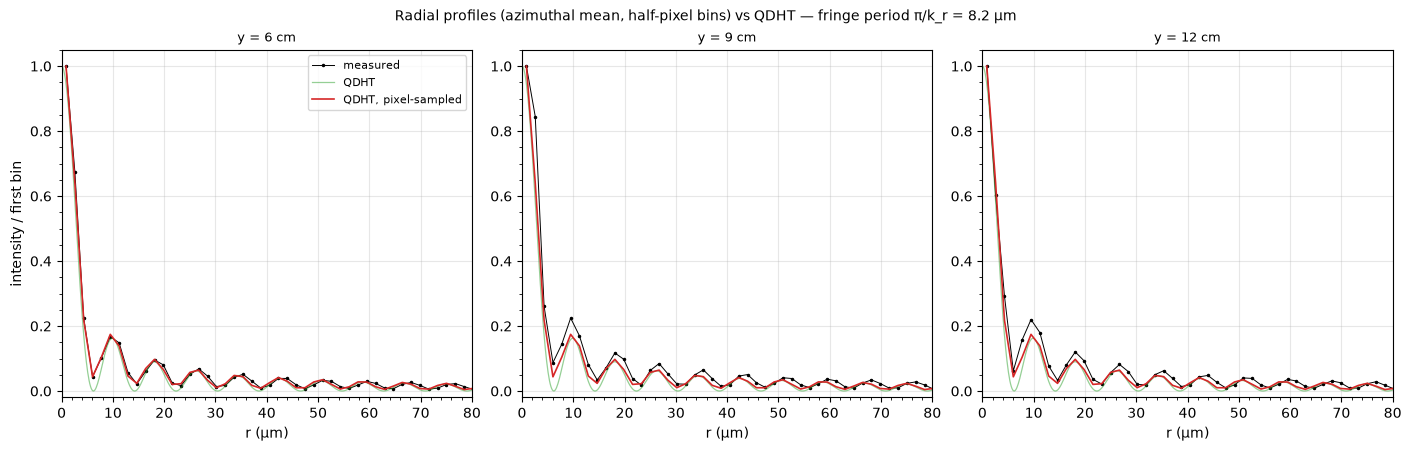

In [7]:
# --- radial comparison figure ------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for ax, y_cm in zip(axs, RADIAL_Y):
    m = measured[y_cm] / measured[y_cm][0]
    ax.plot(r_bins_um, m, "k.-", ms=3, lw=0.7, label="measured")
    ax.plot(r_fine * 1e6, models[y_cm]["fine"], "-", color="tab:green",
            lw=0.9, alpha=0.5, label="QDHT")
    ax.plot(r_bins_um, models[y_cm]["binned"], "-", color="tab:red", lw=1.2,
            label="QDHT, pixel-sampled")
    ax.set_xlim(0, 80); ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("r (µm)")
    ax.set_title(f"y = {y_cm:g} cm", fontsize=9)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
axs[0].set_ylabel("intensity / first bin")
axs[0].legend(fontsize=8)
fig.suptitle("Radial profiles (azimuthal mean, half-pixel bins) vs QDHT — "
             f"fringe period π/k_r = {np.pi / KR_RAO * 1e6:.1f} µm",
             fontsize=10)
save_fig("radial_vs_theory")
plt.show()

### Reading the radial comparison

- **It is a Bessel beam.** Fringe maxima and minima land on the QDHT
  prediction across all three planes with no free parameters — the period
  (8.15 µm), set entirely by k_r, matches through at least nine visible
  orders out to r ≈ 80 µm, and the fringes persist essentially unchanged
  from y = 6 to 12 cm, the diffraction-free signature.
- **Contrast is explained by the camera, not the beam.** The bare J₀²
  fringes at 2.4 px/period should be washed toward the red "pixel-sampled"
  curve, and the measured contrast (e.g. 0.13–0.17 peak-to-valley in
  10–60 µm) matches the replayed model, not the bare one. No need to invoke
  aberrations or partial coherence.
- **The core is under-resolved as expected**: the measured first minimum
  sits near the predicted 6.2 µm but only ~2 bins in, and the central bin
  underestimates true I(0) per the pixel-sampling argument above. Core
  *shape* metrology would need the (planned) microscope-objective relay.
- Slight measured excess over the model in the y = 9 and 12 cm secondary
  maxima (~1–2 % of peak) is consistent with the raw frames carrying no
  background subtraction here — the offset at these tiny exposures is
  below 1 count, visible only once fringe minima approach zero.

## XZ slice gallery

Per-slice ds-2 composites, cropped ±1.75 mm around each slice's brightest
pixel. Every panel is normalized to its **own** max with a γ = 0.4 stretch —
exposures differ slice to slice, so absolute counts are not comparable
between panels (the axial plot above carries the calibrated comparison).
Red titles mark the two flagged slices. The concentric rings are the J₀
fringes; at ds-2 resolution (6.9 µm/px) the 8.15 µm inner fringes are
under-resolved into a core glow, which is why the radial section uses raw
frames instead. By y = 16.5–17 cm the core has handed off to the departing
annulus (and those frames are saturated anyway).

saved images/axicon1_bessel_analysis_2026_07_24/slice_gallery.png


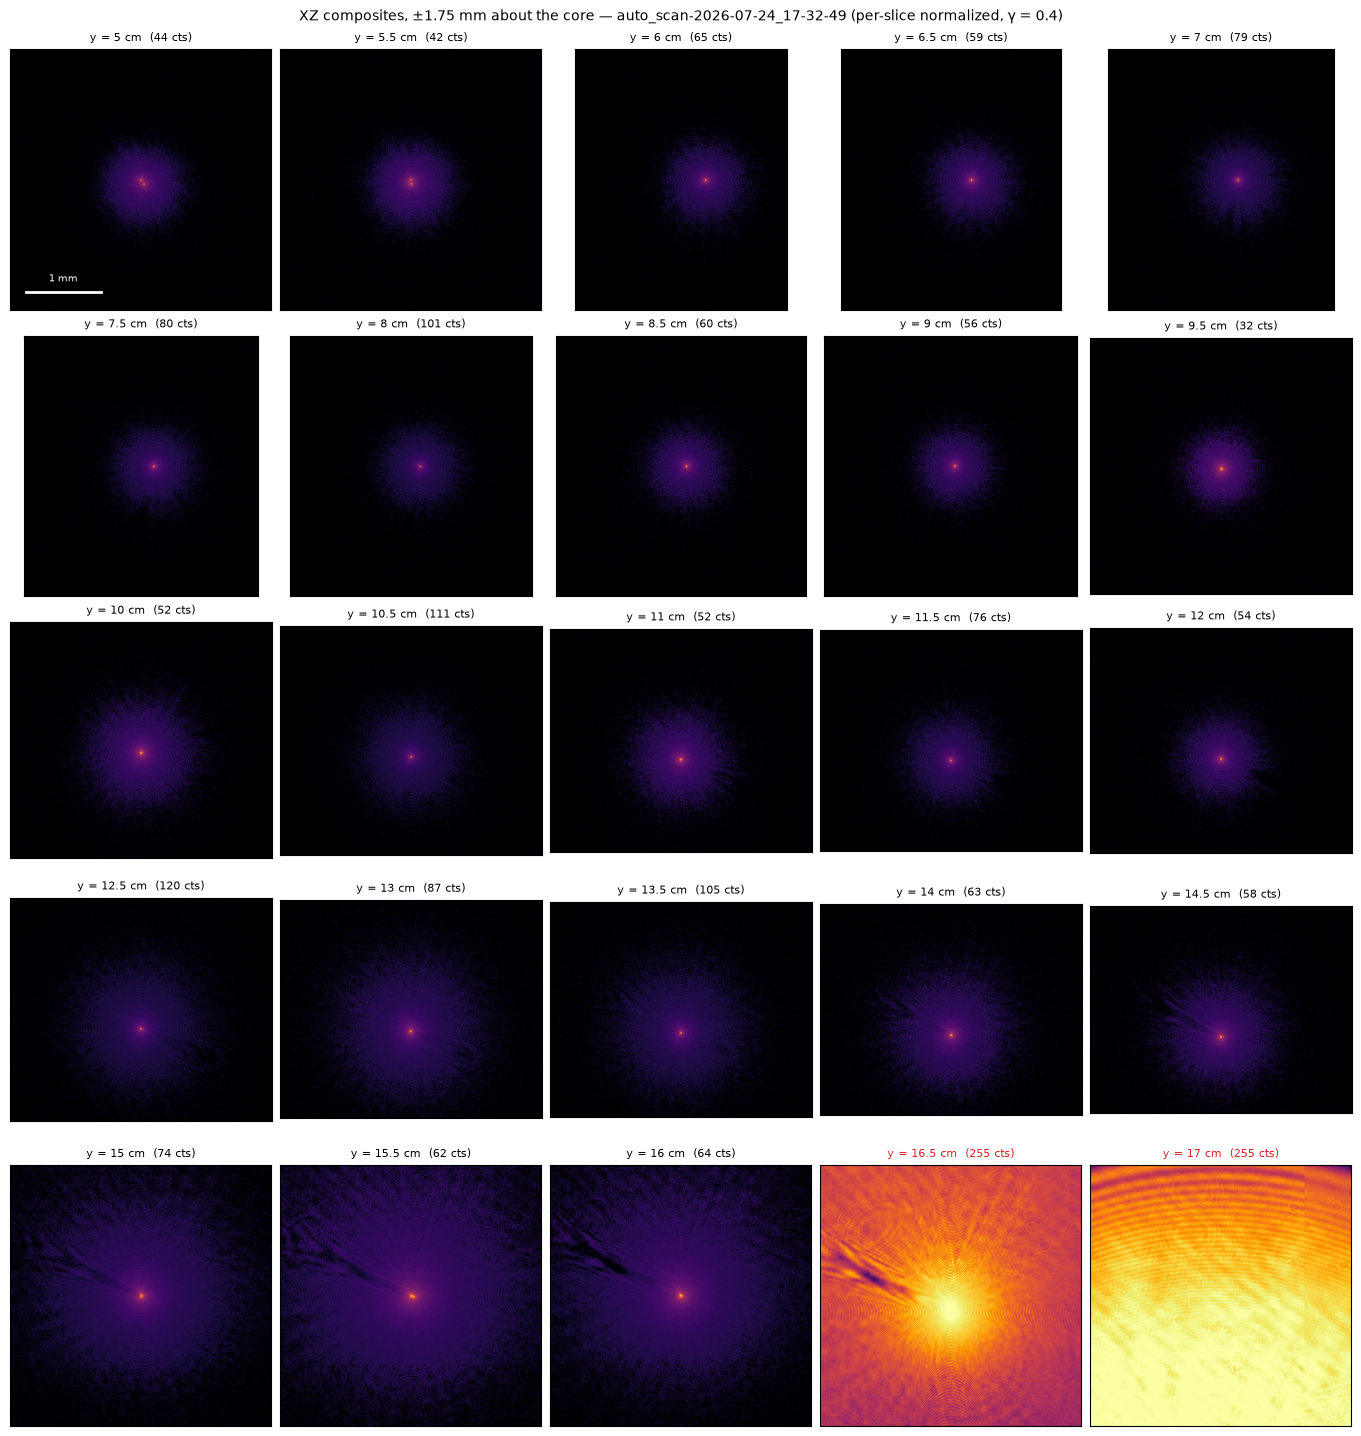

In [8]:
# --- XZ slice gallery --------------------------------------------------------
from matplotlib.colors import PowerNorm

slice_dirs = sorted(glob.glob(str(RUN / "y*cm")))
HALF_MM = 1.75                     # crop half-width around the core
ncol = 5
nrow = int(np.ceil(len(slice_dirs) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(2.7 * ncol, 2.85 * nrow),
                        constrained_layout=True)
for k, (ax, sd) in enumerate(zip(axs.ravel(), slice_dirs)):
    sd = Path(sd)
    comp = np.load(sd / "composite.npy").astype(float)
    meta = json.load(open(sd / "composite_meta.json"))
    s_mm = meta["mm_per_px"]
    half = int(round(HALF_MM / s_mm))
    iy, ix = np.unravel_index(np.argmax(comp), comp.shape)
    r0, r1 = max(iy - half, 0), min(iy + half, comp.shape[0])
    c0, c1 = max(ix - half, 0), min(ix + half, comp.shape[1])
    crop = comp[r0:r1, c0:c1]
    y_cm = meta["BeamY_mm"] / 10.0
    info = next(s for s in reduction if abs(s["beam_y_cm"] - y_cm) < 1e-6)
    bad = info["n_sat"] > 0 and info["peak"]["T"] > 10_000
    ax.imshow(crop, cmap="inferno", norm=PowerNorm(0.4, vmax=crop.max()))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"y = {y_cm:g} cm  ({crop.max():.0f} cts)", fontsize=8,
                 color="tab:red" if bad else "black")
    if k == 0:                     # 1 mm scale bar
        frac = (1.0 / s_mm) / crop.shape[1]
        ax.plot([0.06, 0.06 + frac], [0.07, 0.07], "w-", lw=2,
                transform=ax.transAxes)
        ax.text(0.06 + frac / 2, 0.11, "1 mm", transform=ax.transAxes,
                color="w", fontsize=7, ha="center")
for ax in axs.ravel()[len(slice_dirs):]:
    ax.axis("off")
fig.suptitle(f"XZ composites, ±{HALF_MM:g} mm about the core — {RUN.name} "
             "(per-slice normalized, γ = 0.4)", fontsize=10)
save_fig("slice_gallery")
plt.show()

## Verdict and next steps

Axicon 1 by itself behaves as designed: measured axial envelope, zmax, and
radial fringe structure all agree with Rao/QDHT using the *independently
measured* D = 9.50 mm input — an end-to-end check that the telescope
diameter, the axicon prescription, and the profiler's absolute y-anchoring
(`MeasuredFrom: "axicon1"`) are all consistent.

Next: (1) install axicon 2 and scan the annulus at several L₁₂ candidates,
comparing against `simulate_axicon_pair`; (2) fix or work around the
find-beam exposure escalation before the next long scan (it wrecked the two
slices past 16 cm again); (3) consider a 3×3-sum peak metric in the reducer
to kill the sub-pixel scatter.